# GNSS Fundamentals: Observables, Positioning, and Atmospheric Effects


**Crescent Technical Short Course, Strain Accumulation and Release from GNSS**

**Day 1:** Introduction to GNSS Data  

**Created By:** Brendan Crowell, The Ohio State University, Chair of C3S Working Group

**Data Access:** EarthScope SDK  

**Overview:** This notebook will go over the first half of Day 1 on fundamentals of GNSS. This will obtain some raw GNSS data directly from EarthScope and perform some manipulations on the data. This is in contrast to the historical way of obtaining raw GNSS data from daily or sub-daily RINEX files. The most complex part of using the earthscope-sdk is credentialing, so I suggest you read over their wiki and tutorials on EarthScope's website if you are trying to do this outside of geolab. 

---

## Table of Contents

1. [Setup & Installation](#1-setup--installation)
2. [GNSS Signal Fundamentals](#2-gnss-signal-fundamentals)
3. [Fetching Real GNSS Data with EarthScope SDK](#3-fetching-real-gnss-data-with-earthscope-sdk)
4. [GNSS Observables: Pseudorange and Phase](#4-gnss-observables-pseudorange-and-phase)
5. [Simple Point Positioning](#5-simple-point-positioning)
6. [Ionospheric Delay](#6-ionospheric-delay)
7. [Tropospheric Delay](#7-tropospheric-delay)
8. [Linear Combinations of Phase Observables](#8-linear-combinations-of-phase-observables)
9. [Check for Understanding](#9-check-for-understanding)

---

## 1. Setup & Installation

Install the required packages. The `earthscope-sdk` provides a high-level Python interface to EarthScope GNSS data without needing to download and parse RINEX files manually.

In [1]:
#%pip install earthscope-sdk polars pyarrow numpy matplotlib scipy altair vegafusion vl-convert-python

In [2]:
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import polars as pl
import warnings
warnings.filterwarnings('ignore')

# EarthScope SDK
from earthscope_sdk import AsyncEarthScopeClient

# Styling
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# Physical constants
c       = 299_792_458.0   # speed of light (m/s)
f1      = 1_575.42e6      # GPS L1 carrier frequency (Hz)
f2      = 1_227.60e6      # GPS L2 carrier frequency (Hz)
f5      = 1_176.45e6      # GPS L5 carrier frequency (Hz)
lam1    = c / f1          # L1 wavelength (m) ≈ 0.1903 m
lam2    = c / f2          # L2 wavelength (m) ≈ 0.2442 m

print(f"L1 wavelength: {lam1*100:.2f} cm")
print(f"L2 wavelength: {lam2*100:.2f} cm")
print(f"L1 frequency:  {f1/1e6:.2f} MHz  (= 154 × 10.23 MHz)")
print(f"L2 frequency:  {f2/1e6:.2f} MHz  (= 120 × 10.23 MHz)")

L1 wavelength: 19.03 cm
L2 wavelength: 24.42 cm
L1 frequency:  1575.42 MHz  (= 154 × 10.23 MHz)
L2 frequency:  1227.60 MHz  (= 120 × 10.23 MHz)


---
## 2. GNSS Signal Fundamentals

### 2.1 GPS Signal Structure

GPS satellites transmit at two (now three) carrier frequencies, which are integer multiples of the fundamental frequency $f_0 = 10.23$ MHz:

$$f_1 = 154 \times f_0 = 1575.42 \text{ MHz}$$
$$f_2 = 120 \times f_0 = 1226.60 \text{ MHz}$$
$$f_5 = 115 \times f_0 = 1176.45 \text{ MHz}$$

On each carrier, a **pseudorandom noise (PRN)** code is modulated:
- **C/A code** (Coarse Acquisition): 1.023 MHz, λ ≈ 300 m, L1 only, public
- **P-code** (Precise): 10.23 MHz, λ ≈ 30 m, L1 + L2, originally military

The figure below illustrates how these are layered.

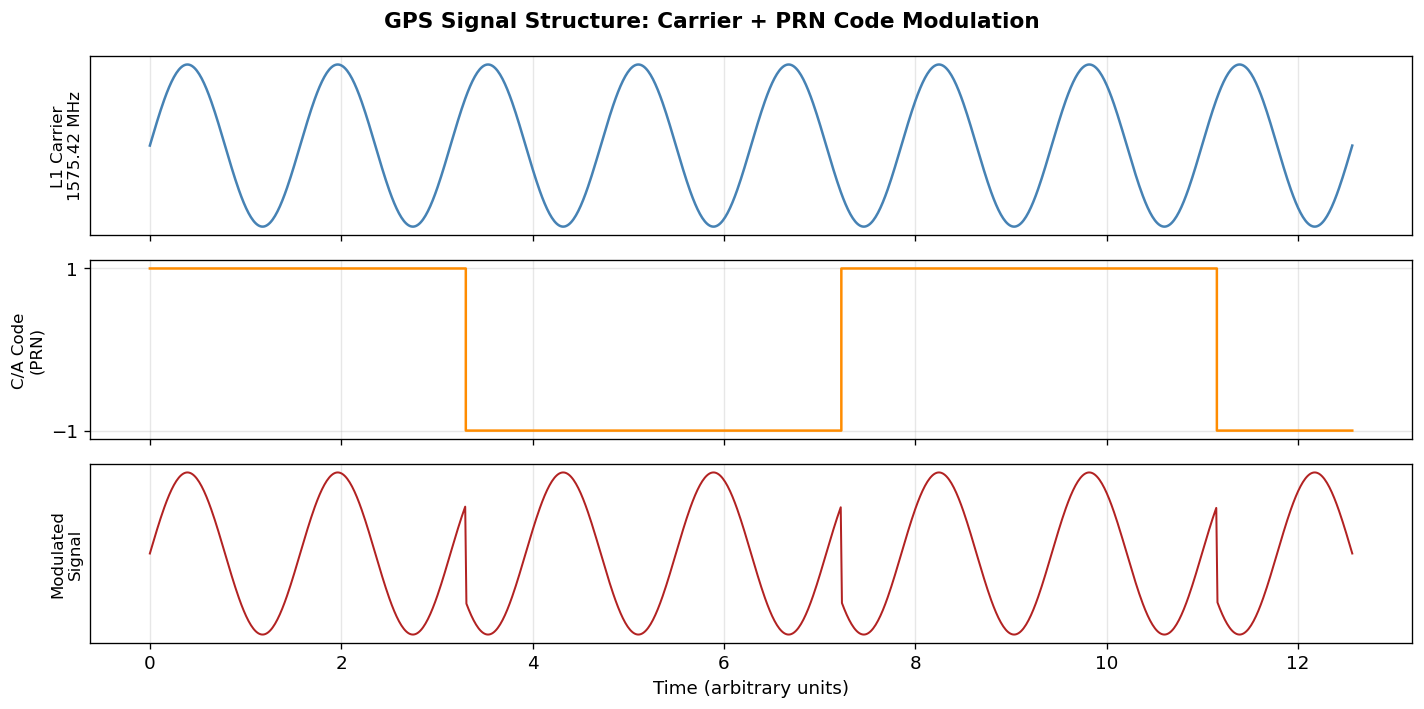

Band   Frequency (MHz)    Wavelength (cm)    Code       Civilian?
-----------------------------------------------------------------
L1     1575.42            19.03              C/A + P(Y) Yes (C/A)
L2     1226.60            24.44              P(Y) + L2C Partial
L5     1176.45            25.48              L5         Yes


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
t = np.linspace(0, 4*np.pi, 1000)

# L1 carrier
axes[0].plot(t, np.sin(t * 4), color='steelblue', lw=1.5)
axes[0].set_ylabel('L1 Carrier\n1575.42 MHz', fontsize=10)
axes[0].set_yticks([])

# C/A code (square wave)
ca_code = np.sign(np.sin(t * 0.8 + 0.5))
axes[1].step(t, ca_code, color='darkorange', lw=1.5, where='mid')
axes[1].set_ylabel('C/A Code\n(PRN)', fontsize=10)
axes[1].set_yticks([-1, 1])

# Modulated signal
modulated = np.sin(t * 4) * ca_code
axes[2].plot(t, modulated, color='firebrick', lw=1.2)
axes[2].set_ylabel('Modulated\nSignal', fontsize=10)
axes[2].set_yticks([])
axes[2].set_xlabel('Time (arbitrary units)')

fig.suptitle('GPS Signal Structure: Carrier + PRN Code Modulation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print a summary table
print(f"{'Band':<6} {'Frequency (MHz)':<18} {'Wavelength (cm)':<18} {'Code':<10} {'Civilian?'}")
print('-' * 65)
for name, freq, code, civ in [
    ('L1', 1575.42, 'C/A + P(Y)', 'Yes (C/A)'),
    ('L2', 1226.60, 'P(Y) + L2C', 'Partial'),
    ('L5', 1176.45, 'L5',         'Yes'),
]:
    lam = c / (freq * 1e6) * 100
    print(f"{name:<6} {freq:<18.2f} {lam:<18.2f} {code:<10} {civ}")

### 2.2 Beat Phase — How Phase is Recorded

The receiver cannot directly record the high-frequency carrier phase. Instead, it **multiplies** the incoming GPS signal $G(t)$ by a locally generated replica carrier $R(t)$. Using trigonometric identities:

$$G(t) \cdot R(t) = \cos(\phi_G) \cdot \cos(\phi_R) = \frac{1}{2}\left[\cos(\phi_G - \phi_R) + \cos(\phi_G + \phi_R)\right]$$

The high-frequency term $\cos(\phi_G + \phi_R)$ is removed by a low-pass filter.  
What remains is the **carrier beat phase**: $\Phi = \phi_G - \phi_R$

This is exactly the difference between receiver and satellite signals — which encodes the range!

---
## 3. Fetching Real GNSS Data with EarthScope SDK

The [EarthScope SDK](https://docs.earthscope.org/sdk/gnss-obs-tutorial) provides direct API access to GNSS observations as Apache Arrow tables — no RINEX parsing required.

### Authentication
You must log in to EarthScope once. The SDK caches your token automatically.

In [4]:
# Initialize the EarthScope client
# On first use, this will prompt you to log in via browser OAuth
es = AsyncEarthScopeClient()
print("EarthScope client initialized.")

EarthScope client initialized.


### 3.1 Download a Day of L1/L2 Pseudorange and Phase

We'll fetch data from station **P717** (PBO network, Pacific Northwest) for a quiet day.  
We request both `phase` and `range` for obs codes `1C` (L1 C/A) and `2W` (L2 P-code).

In [5]:
STATION = "P717"
START   = dt.datetime(2024, 3, 15, 0, 0, 0)   # choose a quiet day
END     = dt.datetime(2024, 3, 15, 23, 59, 59)

print(f"Requesting data for station {STATION}  |  {START.date()}")

table = await es.data.gnss_observations(
    start_datetime=START,
    end_datetime=END,
    station_name=STATION,
    session_name="A",
    system="G",              # GPS only
    obs_code=["1C", "2W"],  # L1 C/A and L2 P
    field=["phase", "range", "snr"],
).fetch()

df_raw = pl.from_arrow(table).sort("timestamp")
print(f"Downloaded {len(df_raw):,} observations")
print(f"Columns: {df_raw.columns}")
df_raw.head(10)

Requesting data for station P717  |  2024-03-15
Downloaded 109,273 observations
Columns: ['timestamp', 'satellite', 'obs_code', 'range', 'phase', 'snr', 'system', 'igs']


timestamp,satellite,obs_code,range,phase,snr,system,igs
"datetime[ms, UTC]",u8,str,f64,f64,f32,str,str
2024-03-15 00:00:00 UTC,5,"""1C""",2.1157e7,-2.0902e7,50.799999,"""G""","""P71700USA"""
2024-03-15 00:00:00 UTC,5,"""2W""",2.1157e7,-1.6226e7,50.900002,"""G""","""P71700USA"""
2024-03-15 00:00:00 UTC,11,"""1C""",2.1899e7,-1.8399e7,46.900002,"""G""","""P71700USA"""
2024-03-15 00:00:00 UTC,11,"""2W""",2.1899e7,-1.4229e7,39.0,"""G""","""P71700USA"""
2024-03-15 00:00:00 UTC,12,"""1C""",2.1772e7,-1.7851e7,48.400002,"""G""","""P71700USA"""
2024-03-15 00:00:00 UTC,12,"""2W""",2.1772e7,-1.3882e7,47.599998,"""G""","""P71700USA"""
2024-03-15 00:00:00 UTC,18,"""1C""",2.5128215e7,-2.3171e6,37.700001,"""G""","""P71700USA"""
2024-03-15 00:00:00 UTC,18,"""2W""",2.5128e7,-1.7524e6,19.6,"""G""","""P71700USA"""
2024-03-15 00:00:00 UTC,20,"""1C""",2.0726e7,-2.3656e7,49.599998,"""G""","""P71700USA"""


In [6]:
# Quick overview of available satellites
sats = df_raw['satellite'].unique().sort()
codes = df_raw['obs_code'].unique().sort()
print(f"Satellites observed: {sats.to_list()}")
print(f"Obs codes:           {codes.to_list()}")
print(f"Time range:          {df_raw['timestamp'].min()} → {df_raw['timestamp'].max()}")

Satellites observed: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
Obs codes:           ['1C', '2W']
Time range:          2024-03-15 00:00:00+00:00 → 2024-03-15 23:59:45+00:00


### 3.2 Visualize Satellite Arcs (SNR)

Signal-to-noise ratio (SNR) gives us a quick view of satellite visibility throughout the day.

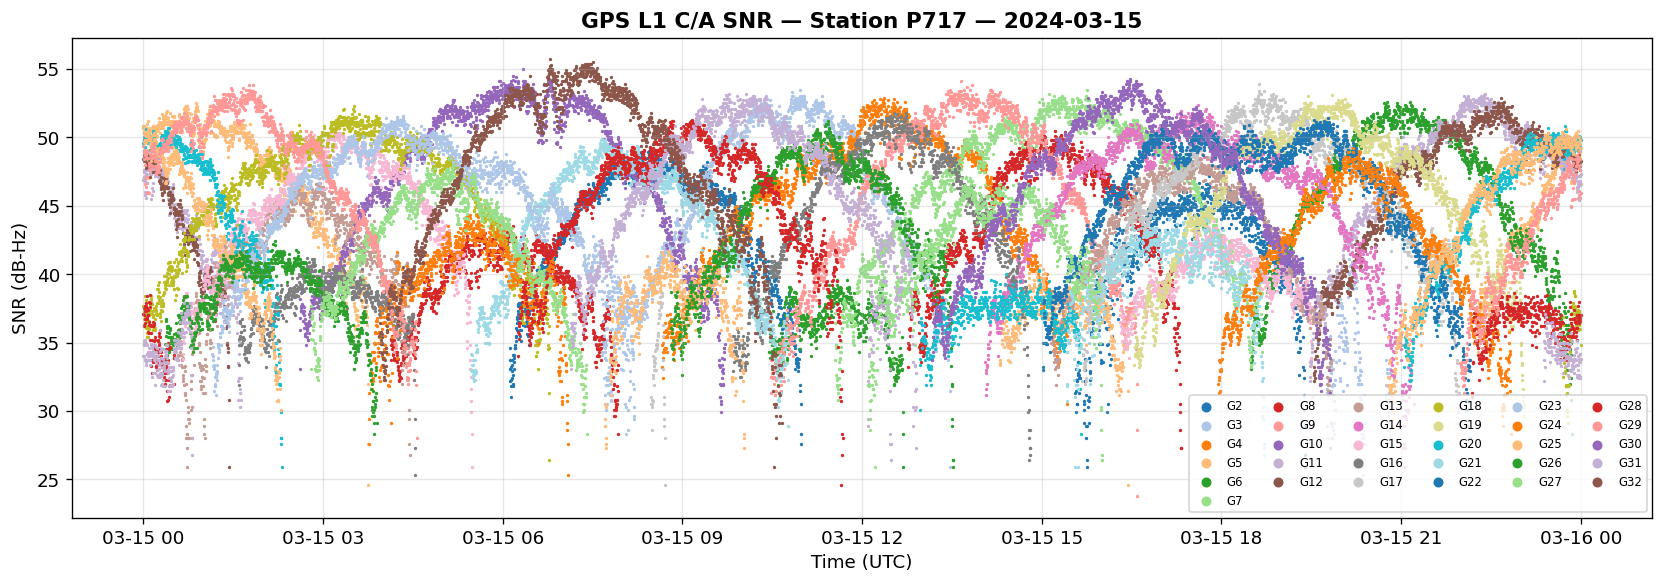

In [7]:
# Plot SNR arcs for 1C observations
df_snr = (
    df_raw
    .filter(pl.col("obs_code") == "1C")
    .filter(pl.col("snr").is_not_null())
)

fig, ax = plt.subplots(figsize=(14, 5))

cmap = plt.cm.tab20
sats_list = sorted(df_snr['satellite'].unique().to_list(), key=int)

for i, sat in enumerate(sats_list):
    sat_df = df_snr.filter(pl.col("satellite") == sat).sort("timestamp")
    times  = sat_df['timestamp'].to_list()
    snr    = sat_df['snr'].to_numpy()
    ax.scatter(times, snr, s=1, color=cmap(i % 20), label=f"G{sat}")

ax.set_xlabel("Time (UTC)")
ax.set_ylabel("SNR (dB-Hz)")
ax.set_title(f"GPS L1 C/A SNR — Station {STATION} — {START.date()}", fontweight='bold')
ax.legend(loc='lower right', ncol=6, fontsize=7, markerscale=5)
plt.tight_layout()
plt.show()

---
## 4. GNSS Observables: Pseudorange and Phase

### 4.1 The Pseudorange Observable

The pseudorange $P$ is the measured time difference between satellite transmit time and receiver receive time, multiplied by $c$. It can be written as:

$$P_i^s = \rho + c(dt_r - dt_s) + T + I_i + \epsilon_P$$

where:
- $\rho$ = true geometric range (m)
- $dt_r, dt_s$ = receiver and satellite clock biases (s)
- $T$ = tropospheric delay (m)
- $I_i$ = ionospheric delay on frequency $i$ (m, **positive** for pseudorange)
- $\epsilon_P$ = measurement noise, multipath

### 4.2 The Phase Observable

Carrier phase $L_i$ (converted to range in meters) is:

$$L_i^s = \rho + c(dt_r - dt_s) + T - I_i + \lambda_i N_i + B_i + \epsilon_L$$

Key difference from pseudorange:
- Ionosphere has **negative** sign (phase advancement, not delay)
- Integer ambiguity $N_i$ — we don't know which cycle we started on
- Sub-centimeter noise (vs. ~30 cm for pseudorange)

### 4.3 Comparing P1 and L1 on Real Data

In [8]:
# Pick one satellite with a long continuous arc
SAT = 7   # PRN G07 — typically well-observed

df_sat = (
    df_raw
    .filter(pl.col("satellite") == SAT)
    .sort("timestamp")
)

# Pivot so 1C and 2W obs are in separate columns
df_pivot = df_sat.pivot(
    values=["phase", "range"],
    index=["timestamp", "satellite"],
    on="obs_code",
).sort("timestamp")

print(f"Pivoted dataframe for satellite G{SAT}:")
df_pivot.head(5)

Pivoted dataframe for satellite G7:


timestamp,satellite,phase_1C,phase_2W,range_1C,range_2W
"datetime[ms, UTC]",u8,f64,f64,f64,f64
2024-03-15 11:32:45 UTC,7,-652480.88327,-463390.102417,2.5540e7,2.5540e7
2024-03-15 11:33:00 UTC,7,-696174.743195,-497437.280151,2.5531e7,2.5531e7
2024-03-15 11:33:15 UTC,7,-739840.679321,-531462.681274,2.5523e7,2.5523e7
2024-03-15 11:33:30 UTC,7,-783486.463409,-565472.358856,2.5515e7,2.5515e7
2024-03-15 11:33:45 UTC,7,-827111.877869,-599466.191162,2.5507e7,2.5507e7


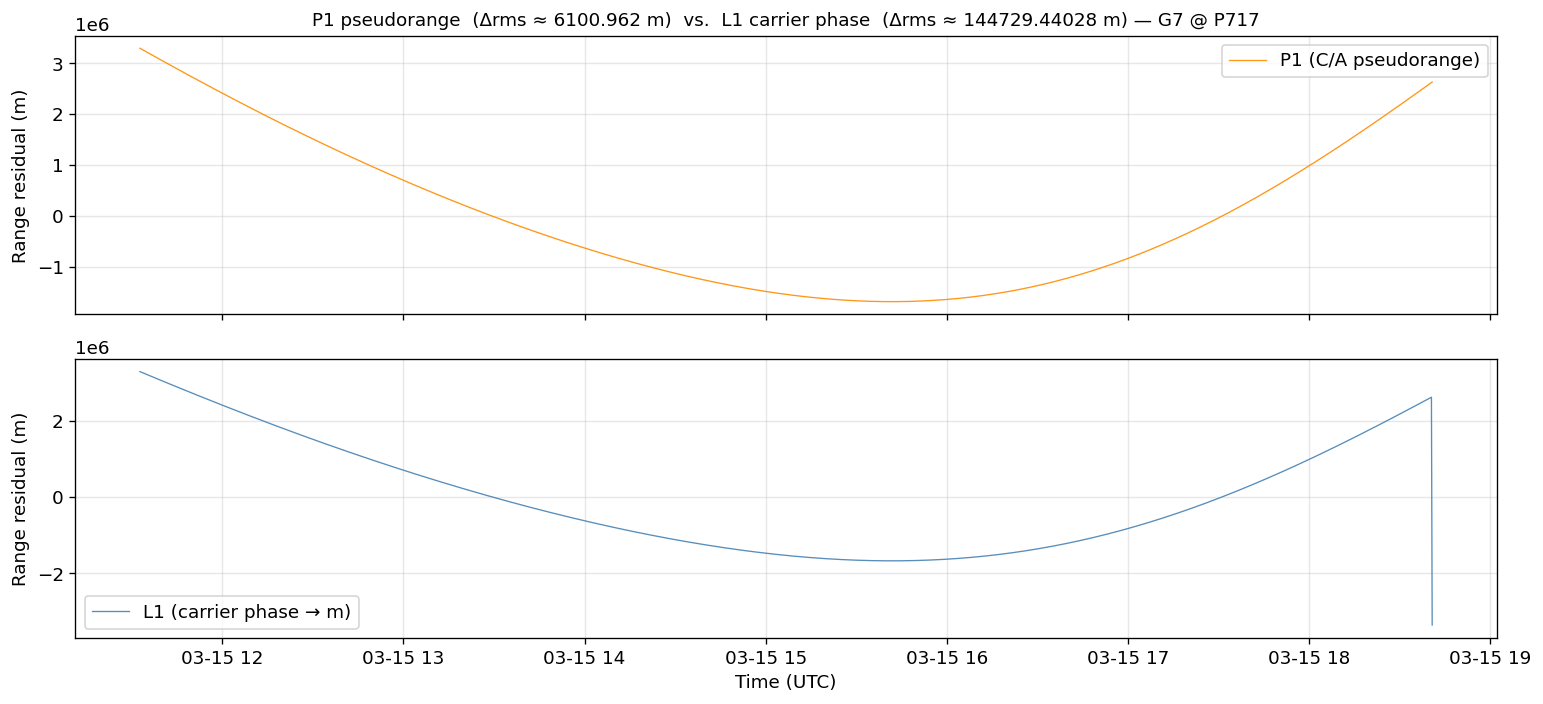


Noise comparison (first-difference RMS):
  P1 pseudorange:  6100.962 m
  L1 carrier phase: 144729.44028 m
  Phase is ~0× less noisy than pseudorange


In [9]:
# Convert phase (cycles) to range (meters)
df_pivot = df_pivot.with_columns([
    (pl.col("phase_1C") * lam1).alias("L1_m"),
    (pl.col("phase_2W") * lam2).alias("L2_m"),
    pl.col("range_1C").alias("P1_m"),
    pl.col("range_2W").alias("P2_m"),
])

# Drop rows with missing values
df_clean = df_pivot.drop_nulls(subset=["L1_m", "L2_m", "P1_m", "P2_m"])

times = df_clean["timestamp"].to_list()
L1 = df_clean["L1_m"].to_numpy()
L2 = df_clean["L2_m"].to_numpy()
P1 = df_clean["P1_m"].to_numpy()
P2 = df_clean["P2_m"].to_numpy()

# Remove mean (the ambiguity + nominal range dominate, so we show residual)
L1_d = L1 - np.nanmean(L1)
P1_d = P1 - np.nanmean(P1)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(times, P1_d, color='darkorange', lw=0.8, label='P1 (C/A pseudorange)', alpha=0.9)
axes[0].set_ylabel("Range residual (m)")
axes[0].set_title(f"L1 Pseudorange vs. Carrier Phase — G{SAT} at {STATION}", fontweight='bold')
axes[0].legend()

axes[1].plot(times, L1_d, color='steelblue', lw=0.8, label='L1 (carrier phase → m)', alpha=0.9)
axes[1].set_ylabel("Range residual (m)")
axes[1].set_xlabel("Time (UTC)")
axes[1].legend()

# Annotate noise difference
p1_std = np.nanstd(np.diff(P1_d))
l1_std = np.nanstd(np.diff(L1_d))
axes[0].set_title(f"P1 pseudorange  (Δrms ≈ {p1_std:.3f} m)  vs.  L1 carrier phase  (Δrms ≈ {l1_std:.5f} m) — G{SAT} @ {STATION}", fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nNoise comparison (first-difference RMS):")
print(f"  P1 pseudorange:  {p1_std:.3f} m")
print(f"  L1 carrier phase: {l1_std:.5f} m")
print(f"  Phase is ~{p1_std/l1_std:.0f}× less noisy than pseudorange")

---
## 5. Simple Point Positioning

### 5.1 Theory: Pseudorange Point Positioning

Given four or more satellites, we can solve for the receiver's position $(x, y, z)$ and clock bias $dt_r$. The observation equation for satellite $s$ is:

$$P^s = \sqrt{(X^s - x)^2 + (Y^s - y)^2 + (Z^s - z)^2} + c \cdot dt_r$$

This is nonlinear, so we linearize via Taylor expansion around an **a priori** position $(x_0, y_0, z_0)$:

$$\delta P^s \approx -\frac{X^s - x_0}{\rho_0^s}\delta x - \frac{Y^s - y_0}{\rho_0^s}\delta y - \frac{Z^s - z_0}{\rho_0^s}\delta z + c\delta t_r$$

Written as a matrix equation $\mathbf{b} = \mathbf{A}\mathbf{x}$, we solve by least squares: $\hat{\mathbf{x}} = (\mathbf{A}^T\mathbf{A})^{-1}\mathbf{A}^T\mathbf{b}$

### 5.2 Dilution of Precision (DOP)

The covariance of the position estimate is proportional to $(\mathbf{A}^T\mathbf{A})^{-1}$. The trace of this matrix (for the 3D position components) defines **PDOP** (Position DOP). Low DOP = satellites well-spread = better geometry.

### 5.3 Simulated Point Positioning Example

In [10]:
def design_matrix(sat_xyz, rcv_approx):
    """Build the design matrix A for point positioning.
    
    sat_xyz   : (N, 3) array of satellite ECEF positions (m)
    rcv_approx: (3,)   array of approximate receiver position (m)
    Returns A : (N, 4) — [dx/rho, dy/rho, dz/rho, c] unit vectors + clock column
    """
    diff = sat_xyz - rcv_approx  # (N, 3)
    rho0 = np.linalg.norm(diff, axis=1, keepdims=True)  # (N, 1)
    los  = -diff / rho0           # (N, 3) line-of-sight unit vectors
    ones = np.ones((len(sat_xyz), 1))
    return np.hstack([los, ones]), rho0.squeeze()


def point_position(sat_xyz, pseudoranges, x0=None, max_iter=10, tol=1e-4):
    """Iterative least-squares point positioning.
    
    sat_xyz     : (N, 3) satellite ECEF positions (m)
    pseudoranges: (N,)   observed pseudoranges (m)
    x0          : initial guess [x, y, z, cdt] — defaults to Earth center
    Returns     : estimated [x, y, z, cdt] in ECEF meters
    """
    if x0 is None:
        x0 = np.zeros(4)          # start at Earth center
    x_est = x0.copy()

    for iteration in range(max_iter):
        A, rho0 = design_matrix(sat_xyz, x_est[:3])
        b = pseudoranges - (rho0 + x_est[3])   # residuals

        delta, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        x_est += delta

        if np.linalg.norm(delta[:3]) < tol:
            print(f"  Converged in {iteration+1} iterations")
            break
    return x_est


# ── Simulate a receiver in Oregon and synthetic satellite geometry ──
# True position: ~Cascades, Oregon  (ECEF)
x_true = np.array([-2_465_957.0, -3_909_034.0, 4_487_345.0])   # m
cdt_true = 30_000.0   # 100 μs clock offset (m equivalent)

# Simulate 6 GPS satellites at MEO (20200 km altitude)
R_MEO = 26_560_000.0   # GPS orbital radius (m)
sat_azimuths = np.deg2rad([30, 100, 160, 220, 290, 350])
sat_elevations = np.deg2rad([20, 55, 30, 45, 60, 25])

# Build satellite ECEF positions (simplified; assume they are in the ECEF frame)
sat_xyz = np.column_stack([
    R_MEO * np.cos(sat_elevations) * np.cos(sat_azimuths),
    R_MEO * np.cos(sat_elevations) * np.sin(sat_azimuths),
    R_MEO * np.sin(sat_elevations)
])

# True pseudoranges (geometry + clock + small random noise 5 m)
rho_true = np.linalg.norm(sat_xyz - x_true, axis=1)
noise = np.random.default_rng(42).normal(0, 5, len(sat_xyz))
P_obs = rho_true + cdt_true + noise

print("Simulated pseudoranges (m):")
for i, (r, p) in enumerate(zip(rho_true, P_obs)):
    print(f"  Sat {i+1}: true range = {r/1e3:.1f} km,  P_obs = {p/1e3:.3f} km")

print("\nRunning point positioning solver...")
x_est = point_position(sat_xyz, P_obs)

pos_error = np.linalg.norm(x_est[:3] - x_true)
clk_error = x_est[3] - cdt_true
print(f"\n3D position error : {pos_error:.2f} m")
print(f"Clock bias error  : {clk_error:.2f} m  ({clk_error/c*1e9:.2f} ns)")

Simulated pseudoranges (m):
  Sat 1: true range = 29488.4 km,  P_obs = 29518.441 km
  Sat 2: true range = 25610.9 km,  P_obs = 25640.883 km
  Sat 3: true range = 24138.2 km,  P_obs = 24168.183 km
  Sat 4: true range = 20323.5 km,  P_obs = 20353.512 km
  Sat 5: true range = 21571.7 km,  P_obs = 21601.664 km
  Sat 6: true range = 27026.4 km,  P_obs = 27056.435 km

Running point positioning solver...
  Converged in 5 iterations

3D position error : 18.88 m
Clock bias error  : 7.96 m  (26.55 ns)


PDOP = 2.41  (< 2.0 is excellent, > 6 is poor)
GDOP = 2.71  (includes clock geometry)


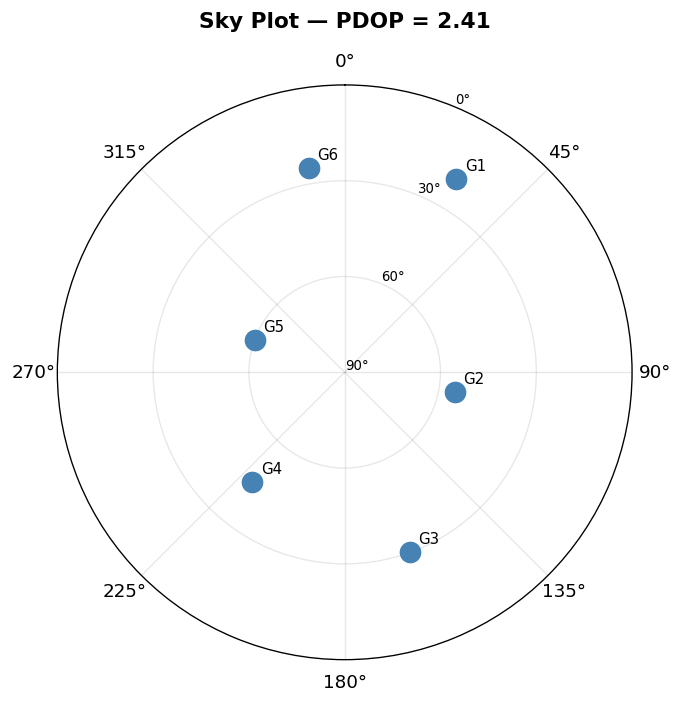

In [11]:
# ── Dilution of Precision (DOP) ──
def compute_dop(sat_xyz, rcv_pos):
    """Compute PDOP and GDOP from satellite geometry."""
    A, _ = design_matrix(sat_xyz, rcv_pos)
    Q = np.linalg.inv(A.T @ A)   # cofactor matrix
    PDOP = np.sqrt(Q[0,0] + Q[1,1] + Q[2,2])
    GDOP = np.sqrt(np.trace(Q))
    return PDOP, GDOP, Q

PDOP, GDOP, Q = compute_dop(sat_xyz, x_est[:3])
print(f"PDOP = {PDOP:.2f}  (< 2.0 is excellent, > 6 is poor)")
print(f"GDOP = {GDOP:.2f}  (includes clock geometry)")

# ── Visualize satellite geometry ──
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax.set_theta_direction(-1)
ax.set_theta_zero_location('N')

elev_plot = 90 - np.rad2deg(sat_elevations)
for i, (az, el) in enumerate(zip(sat_azimuths, elev_plot)):
    ax.plot(az, el, 'o', markersize=12, color='steelblue')
    ax.annotate(f"G{i+1}", (az, el), textcoords='offset points', xytext=(5, 5), fontsize=9)

ax.set_rlim(0, 90)
ax.set_rticks([0, 30, 60, 90])
ax.set_yticklabels(['90°', '60°', '30°', '0°'], fontsize=8)
ax.set_title(f"Sky Plot — PDOP = {PDOP:.2f}", pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Activity: Explore DOP Sensitivity**

Modify the satellite geometry below to see how DOP changes. Try:
1. Clustering all satellites on one side of the sky
2. Adding a satellite directly overhead (elevation = 90°)
3. Reducing to exactly 4 satellites

In [12]:
# ── ACTIVITY: Modify these to explore DOP ──
# Try: all low elevation, or all same azimuth, or very few satellites
test_azimuths   = np.deg2rad([30, 100, 160, 220, 290, 350])  # <-- modify
test_elevations = np.deg2rad([20,  55,  30,  45,  60,  25])  # <-- modify

test_sat_xyz = np.column_stack([
    R_MEO * np.cos(test_elevations) * np.cos(test_azimuths),
    R_MEO * np.cos(test_elevations) * np.sin(test_azimuths),
    R_MEO * np.sin(test_elevations)
])
PDOP_test, GDOP_test, _ = compute_dop(test_sat_xyz, x_true)

print(f"Test configuration:")
print(f"  Number of satellites: {len(test_azimuths)}")
print(f"  PDOP = {PDOP_test:.2f}")
print(f"  GDOP = {GDOP_test:.2f}")

if PDOP_test < 2:
    print("  ✅ Excellent geometry!")
elif PDOP_test < 4:
    print("  ✔  Good geometry")
elif PDOP_test < 6:
    print("  ⚠️  Moderate geometry")
else:
    print("  ❌ Poor geometry — positions will be degraded")

Test configuration:
  Number of satellites: 6
  PDOP = 2.41
  GDOP = 2.71
  ✔  Good geometry


---
## 6. Ionospheric Delay

### 6.1 Physics

The ionosphere (75–1000 km altitude) contains free electrons from solar ionization. It is **dispersive** — the delay depends on signal frequency. GPS codes (group velocity) are **slowed**, while carrier phases (phase velocity) are **advanced**:

$$I_1 = \frac{40.3 \cdot \text{TEC}}{f_1^2}$$

where TEC is Total Electron Content in TECU (1 TECU = $10^{16}$ el/m²). The ratio of L1 to L2 ionospheric delays is just the inverse square of the frequency ratio:

$$\frac{I_2}{I_1} = \frac{f_1^2}{f_2^2} = q^2$$

The TEC affects pseudorange with a **positive** sign and carrier phase with a **negative** sign.

### 6.2 Deriving TEC from Real Data (Geometry-Free Pseudorange)

The geometry-free pseudorange combination removes geometry and troposphere:  
$$P_4 = P_2 - P_1 = I_2 - I_1 = \left(\frac{f_1^2}{f_2^2} - 1\right) \cdot \frac{40.3 \cdot \text{TEC}}{f_1^2}$$

Solving for TEC:
$$\text{TEC} = \frac{P_4 \cdot f_1^2 \cdot f_2^2}{40.3 \cdot (f_1^2 - f_2^2)}$$

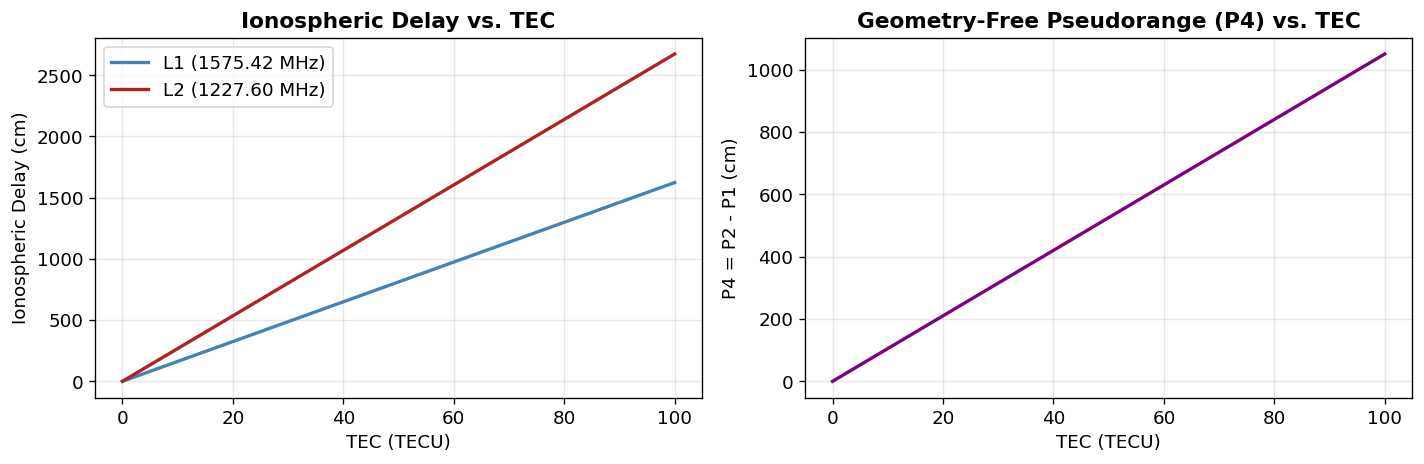

At 10 TECU (quiet day):
  L1 ionosphere: 1.624 m = 162.4 cm
  L2 ionosphere: 2.674 m = 267.4 cm

At 100 TECU (severe storm):
  L1 ionosphere: 16.24 m -- could exceed 50 m!


In [14]:
# ── Model the ionospheric delay as a function of TEC ──
tec_values = np.linspace(0, 100, 200)  # TECU
K = 40.3e16  # constant

I1 = K * tec_values / f1**2  # L1 delay (m)
I2 = K * tec_values / f2**2  # L2 delay (m)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tec_values, I1 * 100, label='L1 (1575.42 MHz)', color='steelblue', lw=2)
axes[0].plot(tec_values, I2 * 100, label='L2 (1227.60 MHz)', color='firebrick', lw=2)
axes[0].set_xlabel("TEC (TECU)")
axes[0].set_ylabel("Ionospheric Delay (cm)")
axes[0].set_title("Ionospheric Delay vs. TEC", fontweight='bold')
axes[0].legend()


# Show P4 combination
P4 = I2 - I1   # geometry-free pseudorange
axes[1].plot(tec_values, P4 * 100, color='purple', lw=2)
axes[1].set_xlabel("TEC (TECU)")
axes[1].set_ylabel("P4 = P2 - P1 (cm)")
axes[1].set_title("Geometry-Free Pseudorange (P4) vs. TEC", fontweight='bold')


plt.tight_layout()
plt.show()

print(f"At 10 TECU (quiet day):")
I1_10 = K * 10 / f1**2
I2_10 = K * 10 / f2**2
print(f"  L1 ionosphere: {I1_10:.3f} m = {I1_10*100:.1f} cm")
print(f"  L2 ionosphere: {I2_10:.3f} m = {I2_10*100:.1f} cm")
print(f"\nAt 100 TECU (severe storm):")
I1_100 = K * 100 / f1**2
print(f"  L1 ionosphere: {I1_100:.2f} m -- could exceed 50 m!")

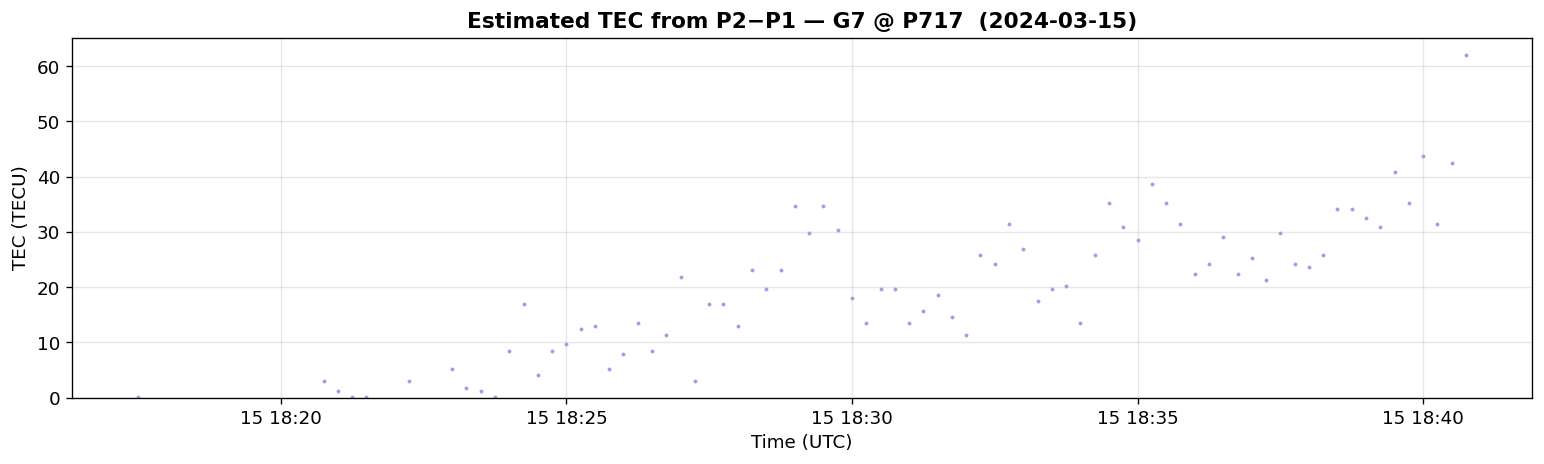

TEC statistics:
  Mean: 20.4 TECU
  Min:  0.1 TECU
  Max:  62.1 TECU

Note: This estimate includes instrumental biases (DCBs).
The diurnal variation reflects true ionospheric TEC change.


In [15]:
# ── Estimate TEC from real P2-P1 data ──
K = 40.3
df_tec = df_clean.with_columns([
    ((pl.col("P2_m") - pl.col("P1_m")) * f1**2 * f2**2 / (K * (f1**2 - f2**2)) / 1e16).alias("TEC_TECU")
])

# Remove obvious outliers
df_tec_clean = df_tec.filter(
    (pl.col("TEC_TECU") > 0) & (pl.col("TEC_TECU") < 200)
)

fig, ax = plt.subplots(figsize=(13, 4))
times = df_tec_clean["timestamp"].to_list()
tec   = df_tec_clean["TEC_TECU"].to_numpy()
ax.scatter(times, tec, s=2, color='mediumpurple', alpha=0.6)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("TEC (TECU)")
ax.set_title(f"Estimated TEC from P2−P1 — G{SAT} @ {STATION}  ({START.date()})", fontweight='bold')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

print(f"TEC statistics:")
print(f"  Mean: {np.nanmean(tec):.1f} TECU")
print(f"  Min:  {np.nanmin(tec):.1f} TECU")
print(f"  Max:  {np.nanmax(tec):.1f} TECU")
print("\nNote: This estimate includes instrumental biases (DCBs).")
print("The diurnal variation reflects true ionospheric TEC change.")

---
## 7. Tropospheric Delay

### 7.1 Theory

The troposphere (0–60 km) is **non-dispersive** at GPS frequencies — the delay is the same for all GPS signals and cannot be estimated from multi-frequency combinations. It is split into two components:

| Component | Acronym | Cause | Predictability |
|-----------|---------|-------|----------------|
| Zenith Hydrostatic Delay | ZHD | Dry air mass | ~99% from surface pressure |
| Zenith Wet Delay | ZWD | Water vapor | Poorly predictable |

**Saastamoinen (1973) ZHD model:**
$$\text{ZHD} = \frac{0.0022768 \cdot P_0}{1 - 0.00266 \cos(2\phi) - 0.00000028 \cdot h}$$

where $P_0$ is surface pressure (mbar), $\phi$ is geodetic latitude, $h$ is ellipsoidal height (m).

**Mapping function:** The slant delay at elevation angle $e$ is:
$$\text{STD} = \text{ZHD} \cdot m_h(e) + \text{ZWD} \cdot m_w(e)$$

A simple mapping function is $m(e) \approx \frac{1}{\sin(e)}$ (though more accurate ones like VMF1 are used in practice).

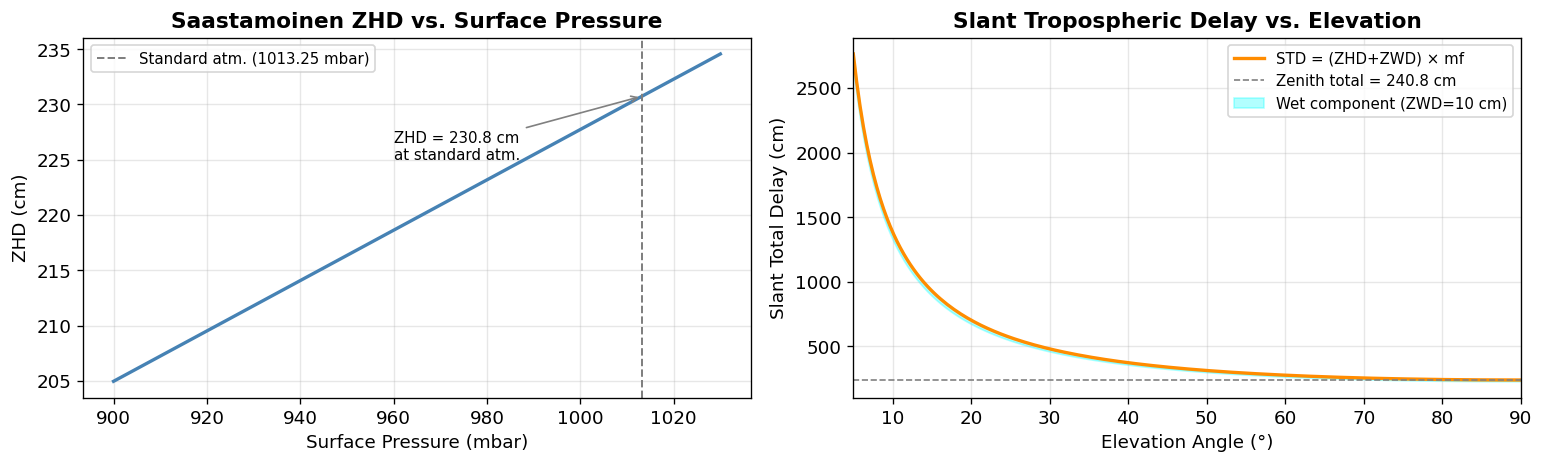

Key values:
  ZHD at standard atm: 2.308 m = 230.8 cm  (~90% of total delay)
  ZWD (typical):       0.100 m = 10.0 cm  (variable, unpredictable)
  Slant delay at 10°:  27.62 m  (12.0× zenith)
  Slant delay at 90°:  2.408 m  (= zenith)


In [16]:
def saastamoinen_zhd(P0_mbar, lat_deg, h_m):
    """Zenith Hydrostatic Delay (m) using Saastamoinen 1973."""
    phi = np.deg2rad(lat_deg)
    return 0.0022768 * P0_mbar / (1 - 0.00266 * np.cos(2*phi) - 0.00000028 * h_m)


def simple_mapping(elev_deg):
    """Simple 1/sin(e) mapping function."""
    return 1.0 / np.sin(np.deg2rad(elev_deg))


# ── ZHD vs latitude and elevation ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: ZHD vs pressure at mid-latitude
P0_range = np.linspace(900, 1030, 100)
lat, h = 44.0, 500.0   # Oregon-ish
ZHD_vals = saastamoinen_zhd(P0_range, lat, h)
axes[0].plot(P0_range, ZHD_vals * 100, color='steelblue', lw=2)
axes[0].axvline(1013.25, color='gray', ls='--', lw=1.2, label='Standard atm. (1013.25 mbar)')
axes[0].set_xlabel("Surface Pressure (mbar)")
axes[0].set_ylabel("ZHD (cm)")
axes[0].set_title("Saastamoinen ZHD vs. Surface Pressure", fontweight='bold')
axes[0].legend(fontsize=9)

zhd_std = saastamoinen_zhd(1013.25, lat, h)
axes[0].annotate(f"ZHD = {zhd_std*100:.1f} cm\nat standard atm.",
                 xy=(1013.25, zhd_std*100), xytext=(960, 225),
                 arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

# Panel 2: Slant delay vs elevation angle
elevations = np.linspace(5, 90, 200)
ZHD = saastamoinen_zhd(1013.25, lat, h)   # ~2.3 m
ZWD = 0.10                                  # typical wet delay ~10 cm
STD = ZHD * simple_mapping(elevations) + ZWD * simple_mapping(elevations)

axes[1].plot(elevations, STD * 100, color='darkorange', lw=2, label='STD = (ZHD+ZWD) × mf')
axes[1].axhline(ZHD*100 + ZWD*100, color='gray', ls='--', lw=1, label=f'Zenith total = {(ZHD+ZWD)*100:.1f} cm')
axes[1].fill_between(elevations, ZHD*simple_mapping(elevations)*100, STD*100,
                     alpha=0.3, color='cyan', label=f'Wet component (ZWD={ZWD*100:.0f} cm)')
axes[1].set_xlabel("Elevation Angle (°)")
axes[1].set_ylabel("Slant Total Delay (cm)")
axes[1].set_title("Slant Tropospheric Delay vs. Elevation", fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(5, 90)

plt.tight_layout()
plt.show()

print("Key values:")
print(f"  ZHD at standard atm: {ZHD:.3f} m = {ZHD*100:.1f} cm  (~90% of total delay)")
print(f"  ZWD (typical):       {ZWD:.3f} m = {ZWD*100:.1f} cm  (variable, unpredictable)")
print(f"  Slant delay at 10°:  {STD[0]:.2f} m  ({STD[0]/ZHD:.1f}× zenith)")
print(f"  Slant delay at 90°:  {STD[-1]:.3f} m  (= zenith)")

In [17]:
# ── Activity: How does pressure/height affect ZHD? ──
print("ZHD comparison across scenarios:")
print(f"{'Scenario':<35} {'P (mbar)':<12} {'h (m)':<10} {'ZHD (cm)'}")
print('-' * 65)

scenarios = [
    ("Sea level, equator",       1013.25,   0,   0.0),
    ("Sea level, mid-latitude",  1013.25,   0,  44.0),
    ("500 m elevation, Oregon",  1000.0,  500,  44.0),
    ("2000 m, mountain",          800.0, 2000,  44.0),
    ("4000 m, high altitude",     600.0, 4000,  44.0),
    ("Storm, low pressure",       980.0,    0,  44.0),
]

for name, P, h, lat in scenarios:
    zhd = saastamoinen_zhd(P, lat, h)
    print(f"{name:<35} {P:<12.2f} {h:<10d} {zhd*100:.2f}")

ZHD comparison across scenarios:
Scenario                            P (mbar)     h (m)      ZHD (cm)
-----------------------------------------------------------------
Sea level, equator                  1013.25      0          231.31
Sea level, mid-latitude             1013.25      0          230.72
500 m elevation, Oregon             1000.00      500        227.73
2000 m, mountain                    800.00       2000       182.26
4000 m, high altitude               600.00       4000       136.77
Storm, low pressure                 980.00       0          223.15


---
## 8. Linear Combinations of Phase Observables

By combining L1 and L2 observations linearly, we can isolate or eliminate specific error sources.

$$L_C = \alpha L_1 + \beta L_2$$

The choice of $\alpha, \beta$ determines what the combination is sensitive to.

---

### 8.1 Ionosphere-Free Combination (LC)

To eliminate the **first-order ionosphere**, we need $\alpha I_1 + \beta I_2 = 0$. Using $I_2 = (f_1^2/f_2^2) I_1$:

$$\alpha + \beta \frac{f_1^2}{f_2^2} = 0  \implies  \beta = -\alpha \frac{f_2^2}{f_1^2}$$

Normalizing ($\alpha - \beta = 1$ so the geometric range is preserved):

$$\alpha = \frac{f_1^2}{f_1^2 - f_2^2}, \quad \beta = -\frac{f_2^2}{f_1^2 - f_2^2}$$

Numerically: $\alpha \approx 2.546$, $\beta \approx -1.546$

The ionosphere-free combination $L_{IF} = \alpha L_1 + \beta L_2$ retains geometry + troposphere + clock.

**Tradeoff:** The noise is amplified by a factor of ~$\sqrt{\alpha^2 + \beta^2} \approx 3\times$.

---

### 8.2 Geometry-Free Combination (L4)

The **geometry-free** combination eliminates all geometry-related terms (satellite position, receiver position, troposphere, clock):

$$L_4 = L_1 - L_2 = (I_2 - I_1) + \lambda_1 N_1 - \lambda_2 N_2 + \text{noise}$$

With stable integer ambiguities, changes in $L_4$ reflect **pure ionospheric variability** — making it ideal for:
- TEC estimation
- Cycle slip detection

---

### 8.3 Melbourne-Wübbena Wide Lane

The Melbourne-Wübbena combination uses both phase and pseudorange to form a wide-lane with a long effective wavelength (~86 cm), making integer ambiguity resolution much easier:

$$L_{MW} = \frac{f_1 L_1 - f_2 L_2}{f_1 - f_2} - \frac{f_1 P_1 + f_2 P_2}{f_1 + f_2}$$

$$\lambda_{WL} = \frac{c}{f_1 - f_2} \approx 86.2 \text{ cm}$$

In [18]:
# ── Compute the combinations ──
alpha_if = f1**2 / (f1**2 - f2**2)
beta_if  = -f2**2 / (f1**2 - f2**2)
lam_wl   = c / (f1 - f2)   # wide-lane wavelength
lam_nl   = c / (f1 + f2)   # narrow-lane wavelength

print("Linear combination coefficients:")
print(f"  Ionosphere-Free: α = {alpha_if:.4f}, β = {beta_if:.4f}")
print(f"  Noise amplification factor: √(α²+β²) = {np.sqrt(alpha_if**2 + beta_if**2):.2f}")
print(f"")
print(f"  Wide-Lane wavelength:   λ_WL = {lam_wl*100:.1f} cm  (→ easier ambiguity resolution)")
print(f"  Narrow-Lane wavelength: λ_NL = {lam_nl*100:.1f} cm  (→ precise, but ambiguous)")
print(f"  L1 wavelength:          λ_L1 = {lam1*100:.1f} cm")
print(f"  L2 wavelength:          λ_L2 = {lam2*100:.1f} cm")

Linear combination coefficients:
  Ionosphere-Free: α = 2.5457, β = -1.5457
  Noise amplification factor: √(α²+β²) = 2.98

  Wide-Lane wavelength:   λ_WL = 86.2 cm  (→ easier ambiguity resolution)
  Narrow-Lane wavelength: λ_NL = 10.7 cm  (→ precise, but ambiguous)
  L1 wavelength:          λ_L1 = 19.0 cm
  L2 wavelength:          λ_L2 = 24.4 cm


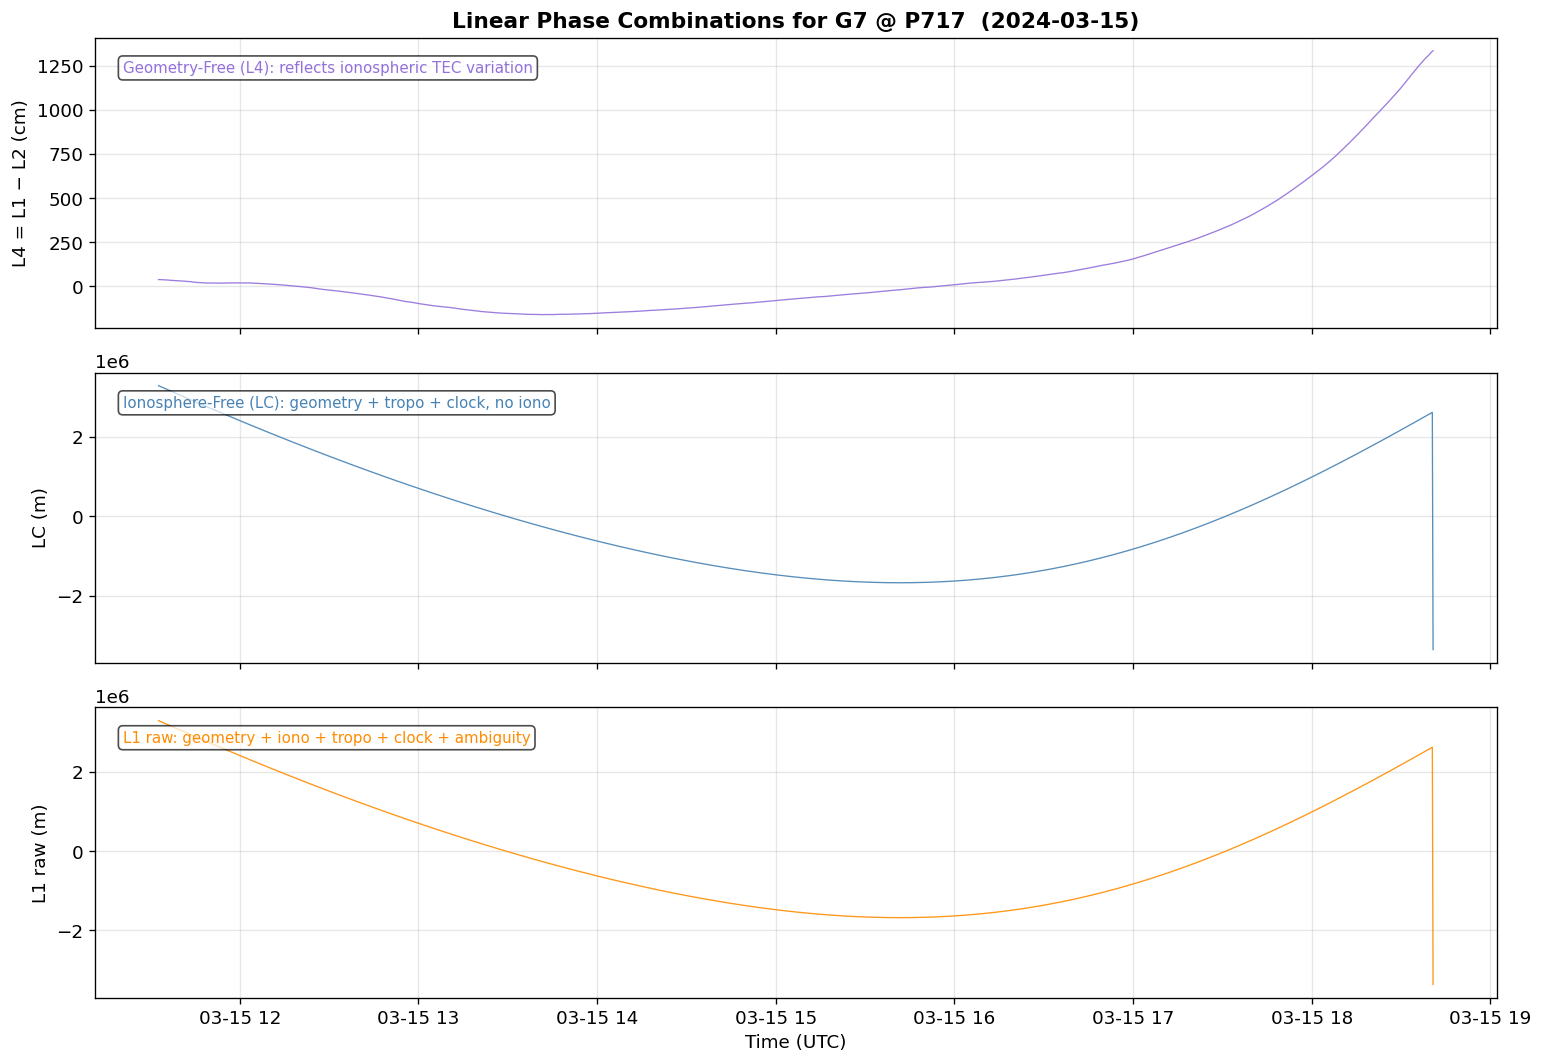

In [19]:
# ── Apply combinations to real data ──
df_comb = df_clean.with_columns([
    # Ionosphere-free phase (meters)
    (alpha_if * pl.col("L1_m") + beta_if * pl.col("L2_m")).alias("LC_m"),
    # Geometry-free phase (meters) - proxy for ionosphere
    (pl.col("L1_m") - pl.col("L2_m")).alias("L4_m"),
    # Melbourne-Wubbena wide lane (cycles)
    (
        (f1 * pl.col("L1_m") / lam1 - f2 * pl.col("L2_m") / lam2) / (f1 - f2)
        - (f1 * pl.col("P1_m") + f2 * pl.col("P2_m")) / (c * (f1 + f2) / (f1 * f2))
        # Simplified: (f1*P1 + f2*P2)/(f1+f2) in meters, then /lambda_wl
    ).alias("MW_WL_cycles"),
])

# Simplified MW-WL: L_WL (cycles) - P_NL (cycles)
# L_WL = (f1*phi1 - f2*phi2)/(f1-f2)  where phi in cycles
# P_NL = (f1*P1 + f2*P2)/c  in cycles
df_comb = df_comb.with_columns([
    (
        (f1 * pl.col("L1_m") / lam1 - f2 * pl.col("L2_m") / lam2) / (f1 - f2)
        - (f1 * pl.col("P1_m") + f2 * pl.col("P2_m")) / (c)
    ).alias("MW_WL_simple")
])

# Detrend L4 (remove integer ambiguity offset)
L4_arr = df_comb["L4_m"].to_numpy()
L4_dt  = L4_arr - np.nanmedian(L4_arr)

# Detrend LC
LC_arr = df_comb["LC_m"].to_numpy()
LC_dt  = LC_arr - np.nanmean(LC_arr)

times = df_comb["timestamp"].to_list()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# L4 — geometry-free
axes[0].plot(times, L4_dt * 100, color='mediumpurple', lw=0.8, alpha=0.9)
axes[0].set_ylabel("L4 = L1 − L2 (cm)")
axes[0].set_title(f"Linear Phase Combinations for G{SAT} @ {STATION}  ({START.date()})", fontweight='bold')
axes[0].text(0.02, 0.88, 'Geometry-Free (L4): reflects ionospheric TEC variation',
             transform=axes[0].transAxes, fontsize=9, color='mediumpurple',
             bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# LC — ionosphere-free
axes[1].plot(times, LC_dt, color='steelblue', lw=0.8, alpha=0.9)
axes[1].set_ylabel("LC (m)")
axes[1].text(0.02, 0.88, 'Ionosphere-Free (LC): geometry + tropo + clock, no iono',
             transform=axes[1].transAxes, fontsize=9, color='steelblue',
             bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# L1 raw for comparison
L1_dt = L1 - np.nanmean(L1)
axes[2].plot(times, L1_dt, color='darkorange', lw=0.8, alpha=0.9)
axes[2].set_ylabel("L1 raw (m)")
axes[2].set_xlabel("Time (UTC)")
axes[2].text(0.02, 0.88, 'L1 raw: geometry + iono + tropo + clock + ambiguity',
             transform=axes[2].transAxes, fontsize=9, color='darkorange',
             bbox=dict(boxstyle='round', fc='white', alpha=0.7))

plt.tight_layout()
plt.show()

In [20]:
# ── Summary table of all combinations ──
import pandas as pd

combos = {
    'Combination': ['L1', 'L2', 'LC (Iono-Free)', 'L4 (Geo-Free)', 'Wide Lane', 'Narrow Lane'],
    'Formula':     ['L1', 'L2', 'αL1 + βL2', 'L1 − L2', '(f1L1−f2L2)/(f1−f2)', '(f1L1+f2L2)/(f1+f2)'],
    'λ (cm)':      [f"{lam1*100:.1f}", f"{lam2*100:.1f}", '~10.7', '~10.7', f"{lam_wl*100:.1f}", f"{lam_nl*100:.1f}"],
    'Iono':        ['Yes', 'Yes', '✗ Removed', '✓ Isolated', '✗ Removed', '✗ Removed'],
    'Geometry':    ['Yes', 'Yes', 'Yes', '✗ Removed', '✗ Removed', 'Yes'],
    'Use case':    [
        'Precise positioning',
        'Precise positioning',
        'Geodetic positioning (PPP, RP)',
        'TEC estimation, cycle slip detection',
        'Integer ambiguity resolution (easy)',
        'Integer ambiguity resolution (precise)',
    ]
}

df_table = pd.DataFrame(combos)
print(df_table.to_string(index=False))

   Combination             Formula λ (cm)       Iono  Geometry                               Use case
            L1                  L1   19.0        Yes       Yes                    Precise positioning
            L2                  L2   24.4        Yes       Yes                    Precise positioning
LC (Iono-Free)           αL1 + βL2  ~10.7  ✗ Removed       Yes         Geodetic positioning (PPP, RP)
 L4 (Geo-Free)             L1 − L2  ~10.7 ✓ Isolated ✗ Removed   TEC estimation, cycle slip detection
     Wide Lane (f1L1−f2L2)/(f1−f2)   86.2  ✗ Removed ✗ Removed    Integer ambiguity resolution (easy)
   Narrow Lane (f1L1+f2L2)/(f1+f2)   10.7  ✗ Removed       Yes Integer ambiguity resolution (precise)


---
## 9. Check for Understanding

Work through these questions to test your grasp of the material. Expand the cells to reveal answers.

In [21]:
# ══════════════════════════════════════════════════
# Q1. Why are 4 satellites (not 3) required for
#     single-point positioning?
# ══════════════════════════════════════════════════

print("Q1: Why are 4 satellites required for point positioning?")
print()
print("There are 4 unknowns to solve:")
print("  (x, y, z) — 3 receiver coordinates")
print("  cδt_r     — receiver clock bias")
print()
print("Each satellite provides one observation (pseudorange),")
print("so we need at least 4 equations (4 satellites) to solve")
print("the system. With >4 satellites, we use least squares.")

Q1: Why are 4 satellites required for point positioning?

There are 4 unknowns to solve:
  (x, y, z) — 3 receiver coordinates
  cδt_r     — receiver clock bias

Each satellite provides one observation (pseudorange),
so we need at least 4 equations (4 satellites) to solve
the system. With >4 satellites, we use least squares.


In [22]:
# ══════════════════════════════════════════════════
# Q2. The ionosphere delays pseudorange but advances
#     carrier phase. Verify this numerically.
# ══════════════════════════════════════════════════

TEC_test = 30.0  # TECU
K = 40.3e16

I1_code  = +K * TEC_test / f1**2   # pseudorange: positive = delay
I1_phase = -K * TEC_test / f1**2   # carrier: negative = advancement

print(f"Q2: At TEC = {TEC_test} TECU on L1:")
print(f"  Pseudorange delay:   +{I1_code:.4f} m  ({I1_code*100:.2f} cm) — signal DELAYED")
print(f"  Carrier phase:       {I1_phase:.4f} m  ({I1_phase*100:.2f} cm) — signal ADVANCED")
print(f"")
print(f"This is why P - L ≈ 2I (twice the ionospheric delay)")
print(f"  P1 - L1 ≈ 2 × I1 = {2*I1_code:.4f} m = {2*I1_code*100:.2f} cm")

Q2: At TEC = 30.0 TECU on L1:
  Pseudorange delay:   +4.8712 m  (487.12 cm) — signal DELAYED
  Carrier phase:       -4.8712 m  (-487.12 cm) — signal ADVANCED

This is why P - L ≈ 2I (twice the ionospheric delay)
  P1 - L1 ≈ 2 × I1 = 9.7423 m = 974.23 cm


In [23]:
# ══════════════════════════════════════════════════
# Q3. Compute the ionosphere-free combination by
#     hand from L1=20,000,000.100 m and
#     L2=20,000,000.150 m.
# ══════════════════════════════════════════════════

L1_val = 20_000_000.100
L2_val = 20_000_000.150

LC = alpha_if * L1_val + beta_if * L2_val

print("Q3: Ionosphere-free combination from L1, L2:")
print(f"  L1 = {L1_val:.3f} m")
print(f"  L2 = {L2_val:.3f} m")
print(f"  α  = {alpha_if:.6f}")
print(f"  β  = {beta_if:.6f}")
print(f"  LC = α·L1 + β·L2 = {LC:.4f} m")
print()
# Geometry free
L4 = L1_val - L2_val
print(f"  L4 = L1 - L2 = {L4:.3f} m  (geometry-free, reflects ~ionosphere + ambiguity)")

Q3: Ionosphere-free combination from L1, L2:
  L1 = 20000000.100 m
  L2 = 20000000.150 m
  α  = 2.545728
  β  = -1.545728
  LC = α·L1 + β·L2 = 20000000.0227 m

  L4 = L1 - L2 = -0.050 m  (geometry-free, reflects ~ionosphere + ambiguity)


In [24]:
# ══════════════════════════════════════════════════
# Q4. How large is the tropospheric delay at 10°
#     elevation vs. 90° elevation?
# ══════════════════════════════════════════════════

ZHD = saastamoinen_zhd(1013.25, 44.0, 0.0)
ZWD = 0.10
ZTD = ZHD + ZWD

elev_10 = 10.0  # degrees
elev_90 = 90.0

STD_10 = ZTD * simple_mapping(elev_10)
STD_90 = ZTD * simple_mapping(elev_90)

print("Q4: Slant tropospheric delay comparison:")
print(f"  ZHD = {ZHD:.3f} m,  ZWD = {ZWD:.3f} m,  ZTD = {ZTD:.3f} m")
print(f"")
print(f"  At elevation 90° (zenith): STD = {STD_90:.3f} m = ZTD")
print(f"  At elevation 10°:          STD = {STD_10:.3f} m  ({STD_10/STD_90:.1f}× larger)")
print(f"")
print("  This is why geodetic processing applies elevation-dependent")
print("  weighting and cutoff angles (typically 10–15°).")

Q4: Slant tropospheric delay comparison:
  ZHD = 2.307 m,  ZWD = 0.100 m,  ZTD = 2.407 m

  At elevation 90° (zenith): STD = 2.407 m = ZTD
  At elevation 10°:          STD = 13.862 m  (5.8× larger)

  This is why geodetic processing applies elevation-dependent
  weighting and cutoff angles (typically 10–15°).


In [25]:
# ══════════════════════════════════════════════════════════════════
# Q5. SYNTHESIS: Simulate realistic pseudorange observation budget
# ══════════════════════════════════════════════════════════════════

rho_true = 22_000_000.0   # geometric range (m)
dt_r     = 1e-6           # receiver clock offset: 1 μs
dt_s     = -5e-9          # satellite clock error: -5 ns
trop     = 2.5            # tropospheric delay (m)
iono     = 5.0            # L1 ionospheric delay (m) at 30 TECU
noise    = 0.3            # measurement noise (m)

P1_obs = rho_true + c * (dt_r - dt_s) + trop + iono + noise

print("Q5: Error budget for a typical L1 pseudorange observation")
print('='*55)
print(f"  Geometric range:       {rho_true/1e6:.6f} × 10⁶ m")
print(f"  Receiver clock (c·δt_r): +{c*dt_r:.3f} m   (300 m @ 1 μs)")
print(f"  Satellite clock:         {c*(dt_s):.6f} m   (-1.5 m @ 5 ns)")
print(f"  Tropospheric delay:      +{trop:.1f} m")
print(f"  Ionospheric delay (L1):  +{iono:.1f} m  (at 30 TECU)")
print(f"  Measurement noise:       +{noise:.1f} m")
print(f"  ─────────────────────────────")
print(f"  P1 observed:            {P1_obs/1e6:.6f} × 10⁶ m")
print()
print("Error magnitudes:")
print(f"  Iono >> Tropo >> Noise >> Sat clock")
print(f"  {iono} m  >> {trop} m >> {noise} m >> {abs(c*dt_s):.1f} m")

Q5: Error budget for a typical L1 pseudorange observation
  Geometric range:       22.000000 × 10⁶ m
  Receiver clock (c·δt_r): +299.792 m   (300 m @ 1 μs)
  Satellite clock:         -1.498962 m   (-1.5 m @ 5 ns)
  Tropospheric delay:      +2.5 m
  Ionospheric delay (L1):  +5.0 m  (at 30 TECU)
  Measurement noise:       +0.3 m
  ─────────────────────────────
  P1 observed:            22.000309 × 10⁶ m

Error magnitudes:
  Iono >> Tropo >> Noise >> Sat clock
  5.0 m  >> 2.5 m >> 0.3 m >> 1.5 m


---
## Summary

| Topic | Key Equations | Key Facts |
|-------|--------------|----------|
| Pseudorange | $P = \rho + c(dt_r-dt_s) + T + I$ | Noise ~30 cm–3 m |
| Carrier Phase | $L = \rho + c(dt_r-dt_s) + T - I + \lambda N$ | Noise ~1–3 mm |
| Point Positioning | $\mathbf{b}=\mathbf{A}\hat{\mathbf{x}}$, 4+ satellites needed | Need clock as 4th unknown |
| DOP | $\text{PDOP} = \sqrt{\text{tr}((A^TA)^{-1})_{xyz}}$ | Low DOP = good geometry |
| Ionosphere | $I = 40.3 \cdot \text{TEC}/f^2$ | Dispersive; opposite signs on P vs L |
| Troposphere | ZHD from Saastamoinen; ZWD from WVR/model | Non-dispersive; mapping function needed |
| Iono-Free LC | $\alpha = f_1^2/(f_1^2-f_2^2)$ | Removes 1st-order iono; amplifies noise |
| Geo-Free L4 | $L_4 = L_1 - L_2$ | Isolates ionosphere; cycle slip detection |
| MW Wide Lane | $\lambda_{WL} = 86.2$ cm | Long wavelength → easier ambiguity resolution |

---

**Further reading:**
- [EarthScope SDK docs](https://docs.earthscope.org/sdk)
- Leick, Rapoport & Tatarnikov, *GPS Satellite Surveying* (4th ed.)
- Hofmann-Wellenhof et al., *GNSS — Global Navigation Satellite Systems*
- [IGS Products](https://www.igs.org/products/)